In [2]:
import pygame
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque  ## multiple frame

print(torch.cuda.is_available())  # 應該為 True
print(torch.version.cuda)         # 應該列出 CUDA 版本
print(torch.backends.cudnn.version())  # cuDNN 版本

script_dir = os.path.join(os.getcwd(), 'space_ship_game_RL')
if script_dir not in sys.path:
    sys.path.append(script_dir)

from setting import *
from game import Game
from Env import SpaceShipEnv

class MLPDDQN(nn.Module):
    def __init__(self, input_dim, num_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )
    def forward(self, x):
        return self.net(x)

pygame 2.6.1 (SDL 2.28.4, Python 3.12.11)
Hello from the pygame community. https://www.pygame.org/contribute.html
True
12.8
90701


In [3]:
version = "v2.4.5"
episode = "1800"
ckpt_path = f"{version}/checkpoint_ep{episode}.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

env = SpaceShipEnv()
state_np = env.reset()                              
input_dim  = state_np.shape[0]
num_actions = 4

model = MLPDDQN(input_dim, num_actions).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['policy_net'])
# model.load_state_dict(ckpt)
model.eval()

# --- 先初始化 ---
best_score = float('-inf')
best_reward = float('-inf')
best_score_frames = []
best_reward_frames = []

NUM_EPISODES = 50
all_scores = []
all_rewards = []

for ep in range(NUM_EPISODES):
    state = env.reset()      # 重置並取得初始 state
    done = False
    total_reward = 0
    frames = []

    # 只要你的 render 是打開視窗用的，可以選擇放在 while 裡或前面呼叫一次
    env.render()

    while not done:
        state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
        with torch.no_grad():
            action = model(state_tensor).argmax(dim=1).item()

        next_state, reward, done, score = env.step(action)
        total_reward += reward
        state = next_state

        # 擷取畫面
        surface = pygame.display.get_surface()
        frame = np.transpose(pygame.surfarray.array3d(surface), (1, 0, 2))
        frames.append(frame)

        pygame.event.pump()

    print(f"Episode {ep+1}: total_reward={total_reward:.2f}, score={score}")    

    all_scores.append(score)
    all_rewards.append(total_reward)
    # 更新並複製
    if score > best_score:
        best_score = score
        best_score_frames = frames.copy()
    if total_reward > best_reward:
        best_reward = total_reward
        best_reward_frames = frames.copy()


env.close()

avg_score = np.mean(all_scores)
std_score = np.std(all_scores)
avg_reward = np.mean(all_rewards)
std_reward = np.std(all_rewards)

print(f"Best score: {best_score}, Best reward: {best_reward}")
print(f"Score — 平均: {avg_score:.2f}, 標準差: {std_score:.2f}")
print(f"Reward — 平均: {avg_reward:.2f}, 標準差: {std_reward:.2f}")

Using device: cuda
Episode 1: total_reward=-278.28, score=1380
Episode 2: total_reward=-139.90, score=1444
Episode 3: total_reward=511.35, score=2686
Episode 4: total_reward=844.43, score=5872
Episode 5: total_reward=151.06, score=1846
Episode 6: total_reward=1253.28, score=5082
Episode 7: total_reward=1748.23, score=5362
Episode 8: total_reward=-454.59, score=1492
Episode 9: total_reward=283.82, score=2156
Episode 10: total_reward=95.56, score=3442
Episode 11: total_reward=41.61, score=1452
Episode 12: total_reward=-184.85, score=2076
Episode 13: total_reward=-211.10, score=912
Episode 14: total_reward=531.39, score=3592
Episode 15: total_reward=1869.88, score=9330
Episode 16: total_reward=-266.97, score=2666
Episode 17: total_reward=3014.82, score=10012
Episode 18: total_reward=-289.38, score=1178
Episode 19: total_reward=-186.92, score=876
Episode 20: total_reward=106.31, score=2686
Episode 21: total_reward=-248.98, score=1586
Episode 22: total_reward=2626.52, score=10036
Episode 23

In [ ]:
import imageio

# video_path = f"video/{version}_ep{episode}_{score}.mp4"
# imageio.mimsave(video_path, frames, fps=60, quality=9)
# print(f"Saved gameplay video to: {video_path}")

imageio.mimsave(f'video/{version}_ep{episode}_{best_score}.mp4', best_score_frames, fps=60, quality=9)
imageio.mimsave(f'video/{version}_ep{episode}_{int(best_reward)}.mp4', best_reward_frames, fps=60, quality=9)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (250, 300) to (256, 304) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Loaded checkpoint from episode 1800, best_avg_score: -inf, epsilon=0.200


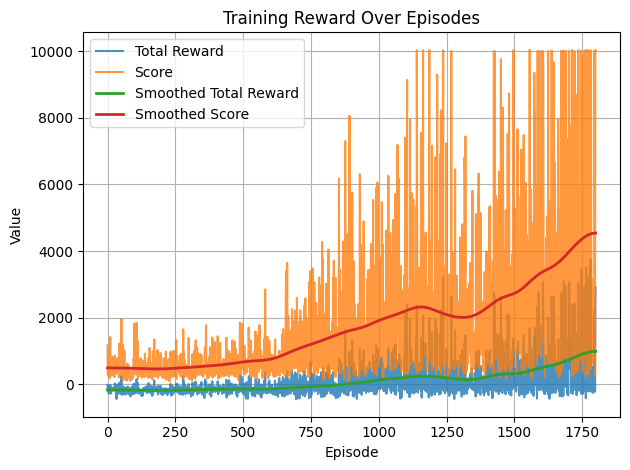

In [4]:
from scipy.ndimage import gaussian_filter1d

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    start_episode  = ckpt["episode"] + 1
    total_steps    = ckpt["total_steps"]
    best_avg_score = ckpt["best_avg_score"]
    best_avg_reward= ckpt["best_avg_reward"]
    epsilon = max(0.2, ckpt["epsilon"])                   # ★
    reward_history = ckpt['reward_history']
    score_history = ckpt['score_history']
    score_window  = deque(score_history[-100:],  maxlen=100)  # ★
    reward_window = deque(reward_history[-100:], maxlen=100)  # ★
    print(f"Loaded checkpoint from episode {start_episode}, best_avg_score: {best_avg_score:.2f}, epsilon={epsilon:.3f}")

reward_smooth = gaussian_filter1d(reward_history, sigma=50)
score_smooth = gaussian_filter1d(score_history, sigma=50)

# 畫圖
# plt.figure(figsize=(10, 5))
plt.plot(reward_history, label='Total Reward', alpha=0.8)
plt.plot(score_history, label='Score', alpha=0.8)
plt.plot(reward_smooth, label='Smoothed Total Reward', linewidth=2)
plt.plot(score_smooth, label='Smoothed Score', linewidth=2)

plt.legend(loc='upper left')
plt.xlabel("Episode")
plt.ylabel("Value")
plt.title("Training Reward Over Episodes")
plt.grid(True)
plt.tight_layout()
# plt.savefig("dqn_training_curve.png")